# Fast.ai Lession - 1 Getting Started

## About Fast.ai
fastai is a deep learning library which provides practitioners with high-level components
that can quickly and easily provide state-of-the-art results in standard deep learning domains, and
provides researchers with low-level components that can be mixed and matched to build new
approaches. It aims to do both things without substantial compromises in ease of use, flexibility, or
performance.

In [2]:
!pip install -Uqq fastbook # for downloading fast ai book

In [2]:
from fastbook import *

In [4]:
urls = search_images_ddg("luffy photos", max_images=1)
len(urls), urls[0]

(1,
 'http://images5.fanpop.com/image/photos/25700000/Luffy-one-piece-25736986-800-1291.jpg')

In [5]:
dest = Path("sample_pirate.jpg")
if not dest.exists():
    download_url(urls[0], dest, show_progress=True)


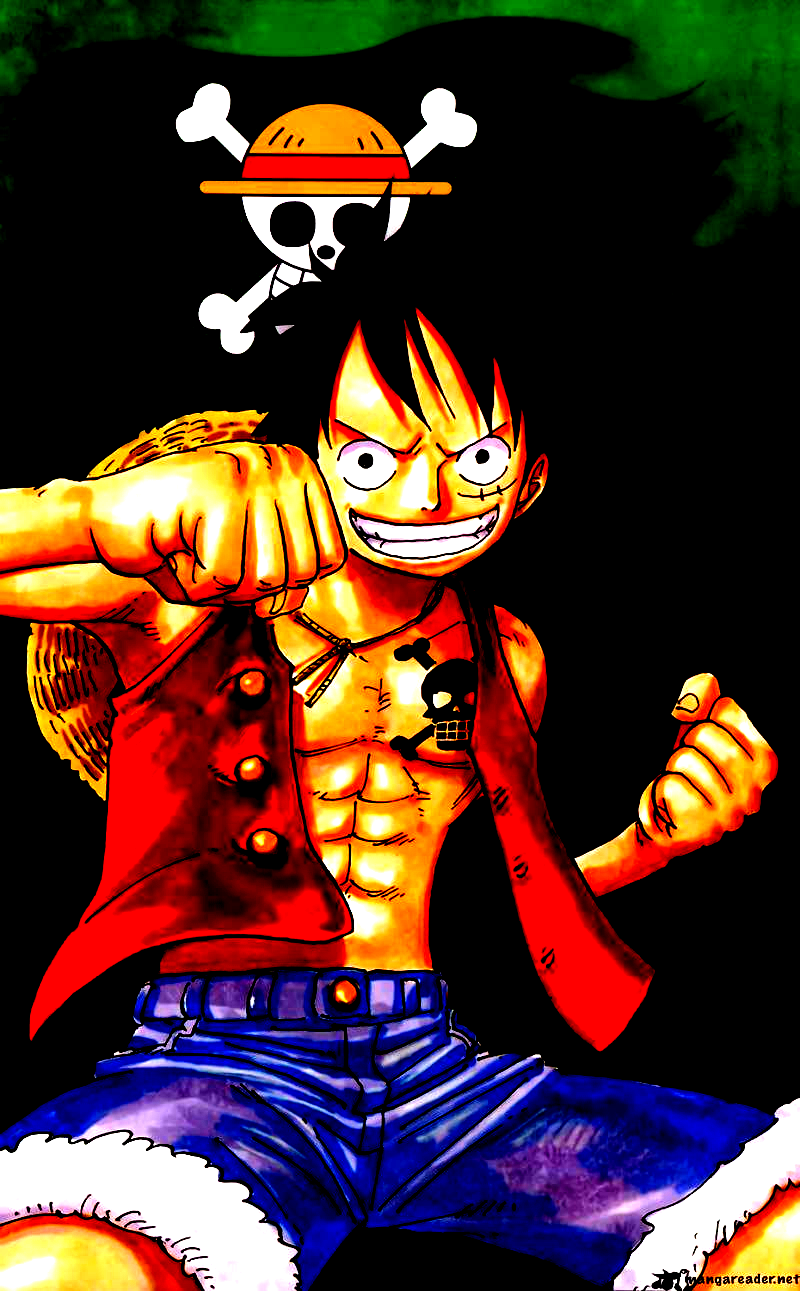

In [6]:
import plotly.express as px

fig = px.imshow(Image.open(dest), color_continuous_scale="Emrld",
                zmin=120, zmax=200)
fig.update_layout(coloraxis_showscale=False,
                  title={
                      "text": "I'm luffy and I'm going to be king of the pirates",
                      "x": .5, "y": .95, "xanchor": "center", "yanchor": "top",
                      }, autosize=True)
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)
fig.show()

In [7]:
dataset_names = ["One piece", "forest"]
path = Path("anime_or_not")

if not path.exists():
    path.mkdir(exist_ok=True)
    for i in dataset_names:
      dest = (path/i)
      dest.mkdir(exist_ok=True)
      results = search_images_ddg(f"{i} photos")
      download_images(dest, urls=results[:200])
      resize_images(dest, max_images=400, dest=dest)

In [8]:
failed = verify_images(get_image_files(path))
failed

(#28) [Path('anime_or_not/One piece/fc4743f7-bd01-4cf8-8bb6-93ccbb5b819f.jpg'),Path('anime_or_not/One piece/3158066b-223c-4f01-a633-ebd49790627c.jpg'),Path('anime_or_not/One piece/24120a46-9807-4fc5-87a8-edc477879f07.jpg'),Path('anime_or_not/One piece/c06d8818-1bc0-4ebc-844d-fa5a6f024a58.jpg'),Path('anime_or_not/One piece/c3878b36-671a-4f6d-8b75-5b8a70a75a2d.jpg'),Path('anime_or_not/One piece/3d2a8d32-f97a-4f69-86e1-5e802d31f501.jpg'),Path('anime_or_not/One piece/56e6fd14-c7dc-46e2-a36d-9ce9ae9f3b9e.jpg'),Path('anime_or_not/One piece/ac8018aa-2077-4567-9a0e-3530edf29265.jpg'),Path('anime_or_not/One piece/65772c15-222e-426d-bced-28933733f5da.jpg'),Path('anime_or_not/One piece/8b271e62-f832-442d-a023-7505ed830993.jpg')...]

In [9]:
failed.map(Path.unlink); # Noo T_T

In [10]:
dataLoaders = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2),
    get_y=parent_label,
    item_tfms=[Resize(192, method="squish")]
).dataloaders(path)

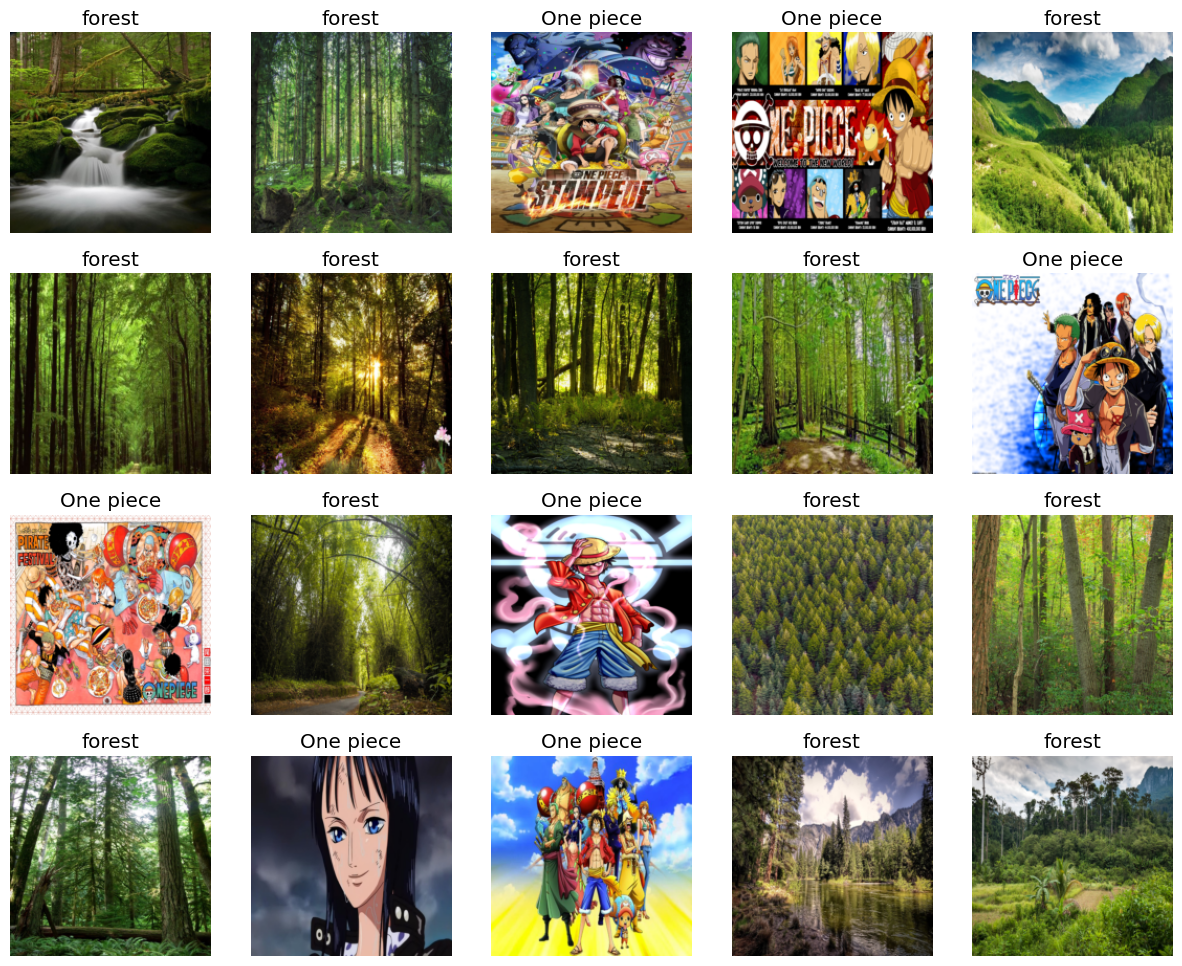

In [11]:
dataLoaders.show_batch(max_n=20)

In [12]:
learn = vision_learner(dataLoaders, resnet18, metrics=error_rate)
learn.fine_tune(3)

/home/niffoxic/Desktop/Ai - Workstation/.env/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.

/home/niffoxic/Desktop/Ai - Workstation/.env/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/niffoxic/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,0.849666,0.713477,0.205882,00:11


epoch,train_loss,valid_loss,error_rate,time
0,0.087822,0.129993,0.058824,00:11
1,0.048252,0.017097,0.000000,00:09
2,0.031081,0.004177,0.000000,00:10


In [13]:
# testing
test_names = ["One Piece"]
test_path = Path("test_images")

if not test_path.exists():
    print("downloading test images please wait.")
    test_path.mkdir(exist_ok=True)
    for i in test_names:
      dest = (test_path/i)
      dest.mkdir(exist_ok=True)
      results = search_images_ddg(f"{i} photos")
      download_images(dest, urls=results[:500])

downloading test images please wait.


In [14]:
failed = verify_images(get_image_files(test_path))
failed.map(Path.unlink);

In [15]:
is_anime, _, probs = learn.predict(PILImage.create("sample_pirate.jpg"))

In [16]:
print(f"labeled as:", is_anime)
print(f"with Probability of:", probs[0])

labeled as: One piece
with Probability of: TensorBase(1.)


In [ ]:
# checking for test_images xD
res = []
for i in get_image_files(test_path):
    x = learn.predict(PILImage.create(i))[0]
    if x == "One piece": res += [1]
    else: res += [0]

In [18]:
print("Test Probability:", sum(res) / len(res)) # daayumm

Test Probability: 1.0


## For segmentation problems

In [3]:
path = untar_data(URLs.CAMVID_TINY)
dataLoaders = SegmentationDataLoaders.from_label_func(
    path, bs=9, fnames=get_image_files(path/"images"),
    label_func=lambda x: path/"labels"/f"{x.stem}_P{x.suffix}",
    codes=np.loadtxt(path/"codes.txt", dtype=str)
)

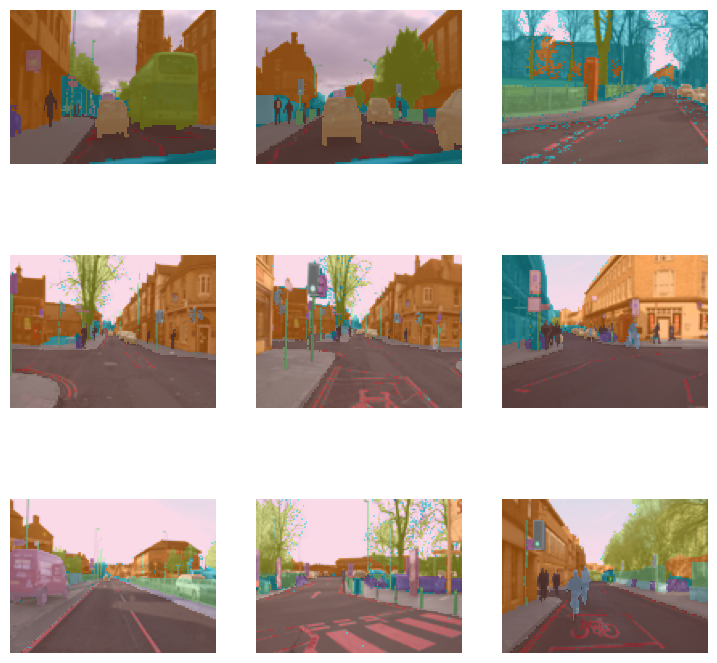

In [4]:
dataLoaders.show_batch(max_n=20)

In [5]:
learner = unet_learner(dataLoaders, resnet34)
learner.fine_tune(8)

/home/niffoxic/Desktop/Ai - Workstation/.env/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/home/niffoxic/Desktop/Ai - Workstation/.env/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


epoch,train_loss,valid_loss,time
0,2.762106,2.489172,00:03


epoch,train_loss,valid_loss,time
0,1.804562,1.674136,00:01
1,1.565652,1.213303,00:01
2,1.383119,1.151130,00:01
3,1.285323,1.034226,00:01
4,1.168407,0.942297,00:01
5,1.062917,0.829858,00:01
6,0.981038,0.794509,00:01
7,0.914201,0.801137,00:01


## Tabular analysis

In [11]:
from fastai.tabular.all import *

In [12]:
path = untar_data(URLs.ADULT_SAMPLE)
dataLoaders = TabularDataLoaders.from_csv(
    path/"adult.csv", path=path, y_names="salary",
    cat_names=["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"],
    cont_names=["age", "fnlwgt", "education-num"],
    procs=[Categorify, FillMissing, Normalize])

In [13]:
dataLoaders.show_batch()

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,education-num_na,age,fnlwgt,education-num,salary
0,State-gov,Bachelors,Never-married,Prof-specialty,Not-in-family,White,Female,United-States,False,32.0,177215.999707,13.0,<50k
1,Private,Some-college,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States,False,60.0,26720.995653,10.0,<50k
2,State-gov,Bachelors,Married-civ-spouse,#na#,Husband,White,Male,United-States,False,58.0,40924.998378,13.0,<50k
3,Private,12th,Never-married,#na#,Own-child,Amer-Indian-Eskimo,Male,United-States,True,23.0,23037.000184,10.0,<50k
4,Private,Bachelors,Divorced,Exec-managerial,Unmarried,White,Female,United-States,False,43.0,498079.008674,13.0,<50k
5,Local-gov,Masters,Divorced,Prof-specialty,Not-in-family,White,Male,United-States,False,59.0,176117.999709,14.0,>=50k
6,Private,Some-college,Divorced,Tech-support,Not-in-family,White,Female,United-States,False,43.0,220609.001256,10.0,<50k
7,Local-gov,Some-college,Never-married,Prof-specialty,Not-in-family,White,Male,United-States,False,21.0,32639.004869,10.0,<50k
8,Private,Assoc-voc,Married-civ-spouse,Machine-op-inspct,Husband,Amer-Indian-Eskimo,Male,United-States,False,31.0,197022.999678,11.0,<50k
9,Private,7th-8th,Divorced,Machine-op-inspct,Unmarried,White,Male,United-States,False,27.0,151381.999834,4.0,<50k


In [14]:
learner = tabular_learner(dataLoaders, metrics=accuracy)
learner.fit_one_cycle(10)

epoch,train_loss,valid_loss,accuracy,time
0,0.459766,0.426045,0.822789,00:02
1,0.368006,0.365046,0.831542,00:02
2,0.356970,0.356247,0.833385,00:02
3,0.361451,0.361895,0.829699,00:02
4,0.347992,0.352819,0.834306,00:02
5,0.351033,0.351599,0.836302,00:02
6,0.338379,0.352871,0.835995,00:02
7,0.352629,0.350213,0.834613,00:02
8,0.335110,0.347387,0.837838,00:02
9,0.336679,0.347140,0.838298,00:02


## Collaborative filtering - recommendation system.

In [15]:
from fastai.collab import *
path = untar_data(URLs.ML_SAMPLE)
dataLoaders = CollabDataLoaders.from_csv(path/"ratings.csv")

In [16]:
dataLoaders.show_batch()

,userId,movieId,rating
0,624,2716,5.0
1,605,588,4.0
2,664,3578,5.0
3,23,6377,3.5
4,460,1136,5.0
5,505,1193,3.5
6,457,34,1.0
7,130,1580,4.0
8,268,1617,3.0
9,605,344,5.0


In [17]:
learner = collab_learner(dataLoaders, y_range=(0.5, 5.5))
learner.fine_tune(10)

epoch,train_loss,valid_loss,time
0,1.519682,1.355460,00:00


epoch,train_loss,valid_loss,time
0,1.367262,1.292447,00:00
1,1.271217,1.106458,00:00
2,1.037511,0.804083,00:00
3,0.798878,0.674223,00:00
4,0.707825,0.642966,00:00
5,0.654170,0.632636,00:00
6,0.642644,0.627704,00:00
7,0.635598,0.624542,00:00
8,0.628716,0.623706,00:00
9,0.625422,0.623661,00:00


In [18]:
learner.show_results()

,userId,movieId,rating,rating_pred
0,16.0,65.0,2.0,3.932071
1,45.0,98.0,1.0,3.470448
2,15.0,41.0,5.0,4.194384
3,33.0,27.0,2.5,3.576478
4,66.0,51.0,4.0,4.237361
5,93.0,51.0,4.0,4.360831
6,11.0,6.0,4.0,3.795784
7,26.0,47.0,3.0,4.553541
8,33.0,28.0,3.5,3.169854


# That's it for the 1st lesson.

skipped mentioning how deep learning works and other basics things because I'm already good at it.
Sources I would suggest for learning deep learning from scratch:
* Deeplearning.ai- coursera.
* A deep understanding of deep learning (with Python intro) - Udemy.